## Import Statements

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from nn.nn import NeuralNetwork

## Load Dataset

In [2]:
digits_dataset = load_digits()


## Splitting Data into Training and Validation Sets

In [3]:
X_train, X_val, y_train, y_val = train_test_split(digits_dataset.data, digits_dataset.data,test_size=0.2, random_state=42)

#normalize data
max_v = digits_dataset.data.max()
X_train = X_train / max_v
X_val = X_val / max_v
y_train = y_train / max_v
y_val = y_val / max_v


## Creating an Instance of Neural Network with 64x16x64 autoencoder architecture

In [23]:
nn_arch = [
    {"input_dim": 64, "output_dim": 16, "activation": "relu"},   
    {"input_dim": 16, "output_dim": 64, "activation": "sigmoid"} 
]

autoencoder = NeuralNetwork(
    nn_arch=nn_arch,
    lr=0.01,
    seed=42,
    batch_size=110,
    epochs=10000,
    loss_function='mean_squared_error' 
)



## Training autoencoder on training data

In [24]:
train_loss, val_loss = autoencoder.fit(X_train, y_train, X_val, y_val)

## Plot training and validation loss by epoch

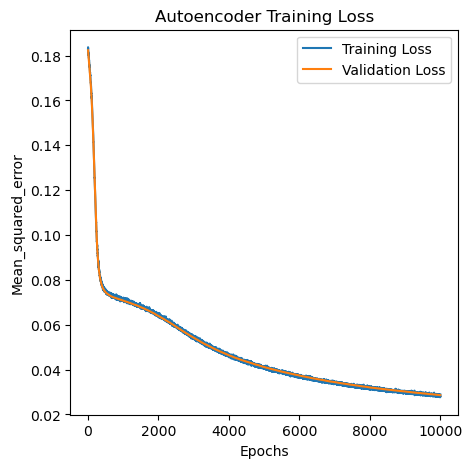

In [25]:
plt.figure(figsize=(5, 5))
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Mean_squared_error')
plt.title('Autoencoder Training Loss')
plt.legend()
plt.show()


## Quantify average reconstruction error over the validation set

In [26]:
y_hat = autoencoder.predict(X_val)
reconstruction_error = np.mean((X_val - y_hat) ** 2)
print(f"Average Reconstruction Error over Validation Set: {reconstruction_error}")


Average Reconstruction Error over Validation Set: 0.02861634188595509


## Explanation of chosen hyperparameter values

### I chose a learning rate of 0.01 because when I first used a higher rate of 0.2 it caused the loss to decrease too slowly and not converge well. I chose a batch size of 110 to balance training speed and gradient stability. The network was trained for 7000 epochs because when I first trained it for 1000 epochs the loss had not reached a plateau yet, but at 7000 the loss reached more of a plateau and the average reconstruction error was minimal. ReLU was used in the hidden layer to introduce non-linearity, while sigmoid was used in the output layer to constrain outputs between 0 and 1, matching the normalized pixel values. MSE was chosen as the loss function because the task is reconstruction of continuous values, not binary classification.